In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/deberta-v3/pytorch/base/2/spm.model
/kaggle/input/deberta-v3/pytorch/base/2/config.json
/kaggle/input/deberta-v3/pytorch/base/2/tokenizer_config.json
/kaggle/input/deberta-v3/pytorch/base/2/pytorch_model.bin
/kaggle/input/jigsaw-agile-community-rules/sample_submission.csv
/kaggle/input/jigsaw-agile-community-rules/train.csv
/kaggle/input/jigsaw-agile-community-rules/test.csv


# Let's delve into the datasets !

In [2]:
train = pd.read_csv('/kaggle/input/jigsaw-agile-community-rules/train.csv')
train.head()

,row_id,body,rule,subreddit,positive_example_1,positive_example_2,negative_example_1,negative_example_2,rule_violation
0,0,Banks don't want you to know this! Click here ...,"No Advertising: Spam, referral links, unsolici...",Futurology,If you could tell your younger self something ...,hunt for lady for jack off in neighbourhood ht...,Watch Golden Globe Awards 2017 Live Online in ...,"DOUBLE CEE x BANDS EPPS - ""BIRDS""\n\nDOWNLOAD/...",0
1,1,SD Stream [ ENG Link 1] (http://www.sportsstre...,"No Advertising: Spam, referral links, unsolici...",soccerstreams,[I wanna kiss you all over! Stunning!](http://...,LOLGA.COM is One of the First Professional Onl...,#Rapper \n🚨Straight Outta Cross Keys SC 🚨YouTu...,[15 Amazing Hidden Features Of Google Search Y...,0
2,2,Lol. Try appealing the ban and say you won't d...,No legal advice: Do not offer or request legal...,pcmasterrace,Don't break up with him or call the cops. If ...,It'll be dismissed: https://en.wikipedia.org/w...,Where is there a site that still works where y...,Because this statement of his is true. It isn'...,1
3,3,she will come your home open her legs with an...,"No Advertising: Spam, referral links, unsolici...",sex,Selling Tyrande codes for 3€ to paypal. PM. \n...,tight pussy watch for your cock get her at thi...,NSFW(obviously) http://spankbang.com/iy3u/vide...,Good News ::Download WhatsApp 2.16.230 APK for...,1
4,4,code free tyrande --->>> [Imgur](http://i.imgu...,"No Advertising: Spam, referral links, unsolici...",hearthstone,wow!! amazing reminds me of the old days.Well...,seek for lady for sex in around http://p77.pl/...,must be watch movie https://sites.google.com/s...,We're streaming Pokemon Veitnamese Crystal RIG...,1


Looking at first at the header we can see make some observations:

* 'body' is the text and comment we are looking at to see if it made rule violations and we can try to check is there are any duplicates
  
* 'rule' is what the comment is juged on so we can maybe try to see if the text contents have words that are related to 'rule', btw we can make categories out of it so looking into its values may be interesting

* 'subreddit' is the forum where it was posted so we can try to look if the 'body' content is related to the theme of the 'subreddit'

* 'positive_examples_n' are comments that violates the rule so we can try to see if the 'body' context has similarity with it and the theme of the content

* 'negative_examples_n' are comments that doesnt violate rules and we can try to see the similarities, the theme of the content and then how different it is from 'postive_examples_n'

* 'rule_violation' indicates if the comment is violating the rule, it is what we will try to predict. 0 if its not and 1 if it is violating rule


In [3]:
test = pd.read_csv('/kaggle/input/jigsaw-agile-community-rules/test.csv')
test.head()

,row_id,body,rule,subreddit,positive_example_1,positive_example_2,negative_example_1,negative_example_2
0,2029,NEW RAP GROUP 17. CHECK US OUT https://soundcl...,"No Advertising: Spam, referral links, unsolici...",hiphopheads,"Hey, guys, just wanted to drop in and invite y...",Cum Swallowing Hottie Katrina Kaif Cartoon Xvi...,SD Stream Eng - [Chelsea TV USA](http://soccer...,HD Streams: |[ENG HD Stoke vs Manchester Unite...
1,2030,Make your life comfortable. Get up to 15% Disc...,No legal advice: Do not offer or request legal...,AskReddit,Get a lawyer and get the security camera foota...,That isn't drastic. You tried reaching out to ...,So what are you going to do with the insurance...,It's just for Austria & Germany. If you still ...
2,2031,Kickin' ass and selling underwear!\nJust made ...,"No Advertising: Spam, referral links, unsolici...",gonewild,Good story my friend. Check out my blog at ht...,If you know what exactly you need then you don...,CENTIPEDES\n\nSOME BASED PATRIOTS HAVE CREATED...,[So great! Thanks for sharing.](http://www.che...
3,2032,watch hooters best therein http://clickan...,"No Advertising: Spam, referral links, unsolici...",personalfinance,"Earn 50,000 bonus points with Chase Sapphire P...","Cool, front page! I made this print along with...",[Full HD Movie Online Free](http://www.flickma...,* Karambit Black Pearl\n* 0.02137822 Float (un...
4,2033,bitches for free at this point show all h...,"No Advertising: Spam, referral links, unsolici...",Showerthoughts,code free tyrande --->>> [Imgur](http://i.imgu...,My trade link\nhttps://steamcommunity.com/trad...,**HD** [ mio Stadium 102 HD](http://www.genti....,Infographics is an incredible method for showi...


* We can see here that the only missing column is 'rule_violation'

In [4]:
sample_submission = pd.read_csv('/kaggle/input/jigsaw-agile-community-rules/sample_submission.csv')
sample_submission.head()

,row_id,rule_violation
0,2029,0.5
1,2030,0.5
2,2031,0.5
3,2032,0.5
4,2033,0.5


* We can see that we will have to return prediction probabilities of if it was rule violation

# Let's sanitize texts 

In [5]:
import re

def replace_urls(text):
    # Pattern to match common URLs
    url_pattern = r'https?://\S+'
    return re.sub(url_pattern, '[URL]', text)

In [6]:
train

,row_id,body,rule,subreddit,positive_example_1,positive_example_2,negative_example_1,negative_example_2,rule_violation
0,0,Banks don't want you to know this! Click here ...,"No Advertising: Spam, referral links, unsolici...",Futurology,If you could tell your younger self something ...,hunt for lady for jack off in neighbourhood ht...,Watch Golden Globe Awards 2017 Live Online in ...,"DOUBLE CEE x BANDS EPPS - ""BIRDS""\n\nDOWNLOAD/...",0
1,1,SD Stream [ ENG Link 1] (http://www.sportsstre...,"No Advertising: Spam, referral links, unsolici...",soccerstreams,[I wanna kiss you all over! Stunning!](http://...,LOLGA.COM is One of the First Professional Onl...,#Rapper \n🚨Straight Outta Cross Keys SC 🚨YouTu...,[15 Amazing Hidden Features Of Google Search Y...,0
2,2,Lol. Try appealing the ban and say you won't d...,No legal advice: Do not offer or request legal...,pcmasterrace,Don't break up with him or call the cops. If ...,It'll be dismissed: https://en.wikipedia.org/w...,Where is there a site that still works where y...,Because this statement of his is true. It isn'...,1
3,3,she will come your home open her legs with an...,"No Advertising: Spam, referral links, unsolici...",sex,Selling Tyrande codes for 3€ to paypal. PM. \n...,tight pussy watch for your cock get her at thi...,NSFW(obviously) http://spankbang.com/iy3u/vide...,Good News ::Download WhatsApp 2.16.230 APK for...,1
4,4,code free tyrande --->>> [Imgur](http://i.imgu...,"No Advertising: Spam, referral links, unsolici...",hearthstone,wow!! amazing reminds me of the old days.Well...,seek for lady for sex in around http://p77.pl/...,must be watch movie https://sites.google.com/s...,We're streaming Pokemon Veitnamese Crystal RIG...,1
...,...,...,...,...,...,...,...,...,...
2024,2024,Please edit your post so it is readable. These...,No legal advice: Do not offer or request legal...,relationships,"I'm not ok with this in anyway, and think you ...",See a lawyer under the guise that you want thi...,"This is just untrue. OP is 13, not an adult -...",Why should I care about all the bicyclists I i...,1
2025,2025,"Yes, and in a right to work state they can eve...",No legal advice: Do not offer or request legal...,legaladvice,Move as much of your assets as you can offshor...,We have great consumer protection laws. There'...,"LPT piratebay, transmission, vpn. Get the musi...","It's not so much that I killed them, it's that...",0
2026,2026,**HD** Streams: |ENG **HD**[ Watch here..PC & ...,"No Advertising: Spam, referral links, unsolici...",soccerstreams,stitopdisca1987.tumblr.com - sex Take girl for...,this girl get sex going to to old http://mrk....,NO ADS | NO ADS | NO ADS\n\nWe show all SOCCER...,[So great! Thanks for sharing.](http://www.che...,1
2027,2027,No. Not when doing so obviously presents a saf...,No legal advice: Do not offer or request legal...,politics,SHE ISNT A BIRTHING CHAMBER BUT EQUALLY THE BA...,"Jail? What are you, ten years old? If they pro...",Who cares about that when I can keep raping in...,send me a private message; I may be able to he...,1


In [7]:
print(replace_urls(train.iloc[0].negative_example_2))

DOUBLE CEE x BANDS EPPS - "BIRDS"

DOWNLOAD/STREAM:

[URL]


In [8]:
# Decode and Encode into UTF-8

def sanitize_text(text):
    """
    Ensures the text is valid UTF-8 by encoding and decoding it.
    Any invalid characters will be replaced with �.
    """
    if not isinstance(text, str):
        text = str(text)
    
    # Encode to UTF-8 bytes, replacing invalid sequences
    encoded = text.encode("utf-8", errors="replace")
    
    # Decode back to string
    return encoded.decode("utf-8", errors="replace")


In [9]:
# Apply both previous function to sanitize text

def clean_text(text):
    """Apply URL replacement and UTF-8 sanitization to text."""
    return sanitize_text(replace_urls(text))

In [10]:
import re
import unicodedata

def cleaner(text):
    """
    Replicates the clean_text.clean function with the same parameters.
    """
    if not isinstance(text, str):
        return text

    # Fix unicode (normalize to NFC form)
    if True:  # fix_unicode=True
        text = unicodedata.normalize('NFC', text)
    
    # Convert to ASCII (remove non-ASCII characters)
    if True:  # to_ascii=True
        text = text.encode('ascii', 'ignore').decode('ascii')
    
    # Handle URLs
    if True:  # no_urls=True
        url_pattern = r'https?://\S+|www\.\S+'
        text = re.sub(url_pattern, '<URL>', text)
    
    # Handle emails
    if True:  # no_emails=True
        email_pattern = r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b'
        text = re.sub(email_pattern, '<EMAIL>', text)
    
    # Handle phone numbers (basic pattern)
    if True:  # no_phone_numbers=True
        phone_pattern = r'\b(?:\+\d{1,2}\s?)?\(?\d{3}\)?[\s.-]?\d{3}[\s.-]?\d{4}\b'
        text = re.sub(phone_pattern, '<PHONE>', text)
    
    # Note: The original clean_text keeps these False, so we don't modify:
    # - lower=False (don't lowercase)
    # - no_line_breaks=False (keep line breaks)
    # - no_numbers=False (keep numbers)
    # - no_digits=False (keep digits)
    # - no_currency_symbols=False (keep currency symbols)
    # - no_punct=False (keep punctuation)
    
    return text

In [11]:
# Let's make a function that builds a prompt out of a row in a dataframe

def build_prompt(row):
    base_prompt = """You are an expert content moderator. Your task is to determine if a given Reddit comment violates a specified subreddit rule. 
Carefully analyze the comment in the context of the rule with the provided example. Only answer by Yes/No"""

    prompt = f"""
{base_prompt}

Subreddit: {row['subreddit']}

Rule: {row['rule']}

Examples:

1) {cleaner(row['positive_example_1'])}
Answer: Yes

2) {cleaner(row['positive_example_2'])}
Answer: Yes

3) {cleaner(row['negative_example_1'])}
Answer: No

4) {cleaner(row['negative_example_2'])}
Answer: No

----

Comment: {cleaner(row['body'])}
Answer:
"""
    return prompt

In [12]:
row = train.iloc[1]
for col, val in row.items():
    print(f"{col}: {val}\n")

row_id: 1

body: SD Stream [ ENG Link 1] (http://www.sportsstreams247.com/astra-giurgiu-vs-fc-austria-wien/)

rule: No Advertising: Spam, referral links, unsolicited advertising, and promotional content are not allowed.

subreddit: soccerstreams

positive_example_1: [I wanna kiss you all over! Stunning!](http://www.oilflush.life/2017/01/26/6/)

positive_example_2: LOLGA.COM is One of the First Professional Online Gold sites. By Now, As A Game Gold Seller, we've over more than 5 yrs Of Experience And Can Pass That On To Our Customers.

negative_example_1: #Rapper 
🚨Straight Outta Cross Keys SC 🚨YouTube Search Beanie 864 Click Link BELOW To Hear Hit Single
  "Ah Man" 
 Beanie 864 FEAT King Kota 
 (King Kota Is Only 15!) Lit 🌡🔥👍💵💯Fr Fr 
https://youtu.be/tLqbV1Jmt5Y

negative_example_2: [15 Amazing Hidden Features Of Google Search You Probably Don’t Know](http://www.madpeoples.com/2017/01/02  No one would argue the fact that Google is one of the most useful sihttp://www.madpeoples.com/2016

In [13]:
print(build_prompt(train.iloc[1]))


You are an expert content moderator. Your task is to determine if a given Reddit comment violates a specified subreddit rule. 
Carefully analyze the comment in the context of the rule with the provided example. Only answer by Yes/No

Subreddit: soccerstreams

Rule: No Advertising: Spam, referral links, unsolicited advertising, and promotional content are not allowed.

Examples:

1) [I wanna kiss you all over! Stunning!](<URL>
Answer: Yes

2) LOLGA.COM is One of the First Professional Online Gold sites. By Now, As A Game Gold Seller, we've over more than 5 yrs Of Experience And Can Pass That On To Our Customers.
Answer: Yes

3) #Rapper 
Straight Outta Cross Keys SC YouTube Search Beanie 864 Click Link BELOW To Hear Hit Single
  "Ah Man" 
 Beanie 864 FEAT King Kota 
 (King Kota Is Only 15!) Lit Fr Fr 
<URL>
Answer: No

4) [15 Amazing Hidden Features Of Google Search You Probably Dont Know](<URL>  No one would argue the fact that Google is one of the most useful si<URL> on the Internet. 

In [14]:
print(len(build_prompt(train.iloc[1])))

1166


# Let's try at first to use classification model using sk learn and a tokenizer

In [15]:
# Let's create a function that create the dataset 

def create_dataset(df: pd.DataFrame) -> pd.DataFrame:
    
    df = df.copy()

    # Apply build_prompt row by row
    prompts = df.apply(build_prompt, axis=1)

    # Build new dataframe
    new_df = pd.DataFrame({
        "text": prompts,
        "label": df["rule_violation"]
    })

    return new_df

In [16]:
train_dataset = create_dataset(train)

In [17]:
train_dataset.head()

,text,label
0,\nYou are an expert content moderator. Your ta...,0
1,\nYou are an expert content moderator. Your ta...,0
2,\nYou are an expert content moderator. Your ta...,1
3,\nYou are an expert content moderator. Your ta...,1
4,\nYou are an expert content moderator. Your ta...,1


In [18]:
train_dataset.text.value_counts()

text
\nYou are an expert content moderator. Your task is to determine if a given Reddit comment violates a specified subreddit rule. \nCarefully analyze the comment in the context of the rule with the provided example. Only answer by Yes/No\n\nSubreddit: legaladvice\n\nRule: No legal advice: Do not offer or request legal advice.\n\nExamples:\n\n1) [Yes, it is. In the USA, at least](<URL>  \n  \nTo put it bluntly, child porn must either show genitals or be sexual in nature. Underwear covers the same as a bathing suit and if all they are doing is standing there, it's perfectly legal.  \n  \nPlease be aware that I'm only pointing out a fact, **not** defending that scumbag. \nAnswer: Yes\n\n2) Never pay a civil demand. \n\nIt's a bluff and no company will ever sue anybody over an amount as small as $500.00\n\n\nAnswer: Yes\n\n3) Where is there a site that still works where you can jump the GPS. Is there a FAQ to do this with iPhone or Mac?\nAnswer: No\n\n4) Steal a car from an elderly pers

# Let's start making the Dataset (to train the model using qwen)

In [19]:
import torch
import numpy as np
from transformers import  TrainingArguments, Trainer, AutoTokenizer
from sklearn.model_selection import train_test_split
from datasets import Dataset
import numpy as np
import transformers 
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"

model_name = "/kaggle/input/deberta-v3/pytorch/base/2"
EPOCHS = 60

tokenizer = AutoTokenizer.from_pretrained(model_name)
MAX_LEN = 512

2025-10-17 10:10:37.045889: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760695837.239328      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760695837.292855      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
/usr/local/lib/python3.11/dist-packages/transformers/convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte 

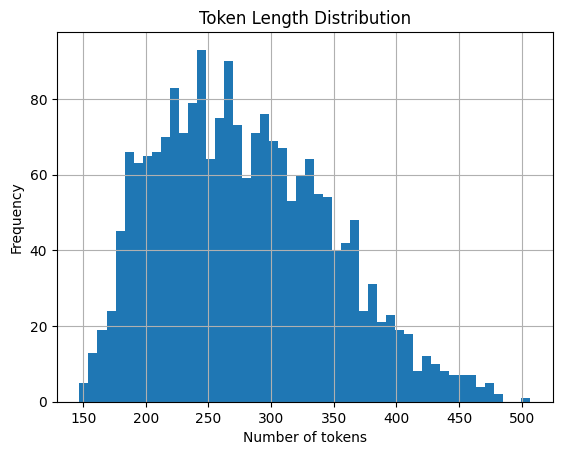

In [20]:
lengths = [len(tokenizer.encode(t, truncation=False)) for t in train_dataset["text"]]
import matplotlib.pyplot as plt

plt.hist(lengths, bins=50)
plt.title("Token Length Distribution")
plt.xlabel("Number of tokens")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

In [21]:
#Split into train and validation sets
train_df, val_df = train_test_split(train_dataset, test_size=0.2, random_state=42)

# Convert to Hugging Face Dataset
COLS = ['text','label']
train_ds = Dataset.from_pandas(train_df[COLS])
val_ds = Dataset.from_pandas(val_df[COLS])

In [22]:
# Tokenization function
def tokenize(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=MAX_LEN)

train_ds = train_ds.map(tokenize, batched=True)
val_ds = val_ds.map(tokenize, batched=True)

# Set format for PyTorch
columns = ['input_ids', 'attention_mask', 'label']
train_ds.set_format(type='torch', columns=columns)
val_ds.set_format(type='torch', columns=columns)

Map:   0%|          | 0/1623 [00:00<?, ? examples/s]

Map:   0%|          | 0/406 [00:00<?, ? examples/s]

In [23]:
from transformers import DebertaV2ForSequenceClassification

model = DebertaV2ForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at /kaggle/input/deberta-v3/pytorch/base/2 and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [24]:
from sklearn.metrics import roc_auc_score, accuracy_score

# Define compute_metrics function for ROC AUC
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = torch.softmax(torch.tensor(predictions), dim=-1).numpy()
    
    pred_probs = predictions[:, 1]
    
    # Calculate ROC AUC
    auc = roc_auc_score(labels, pred_probs)
    
    # Also calculate accuracy for reference
    preds = np.argmax(predictions, axis=1)
    accuracy = accuracy_score(labels, preds)
    
    return {
        'roc_auc': auc,
        'accuracy': accuracy,
    }

In [25]:
DIR = f"DebertaV3LARGE"
os.makedirs(DIR, exist_ok=True)

training_args = TrainingArguments(
    output_dir = f"./{DIR}",
    do_train=True,
    do_eval=True,
    eval_strategy="steps",
    save_strategy="steps", #no for no saving 
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=16,
    #gradient_accumulation_steps=8,
    per_device_eval_batch_size=32,
    
    learning_rate=5e-5,
    logging_dir="./logs",
    fp16=True,
    logging_steps=50,
    save_steps=200,
    eval_steps=200,
    save_total_limit=1,
    metric_for_best_model="roc_auc",
    greater_is_better=True,
    load_best_model_at_end=True,
    report_to="none",
)

In [26]:
# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

trainer.train()

/tmp/ipykernel_19/3917641152.py:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss,Validation Loss,Roc Auc,Accuracy
200,0.700300,0.719842,0.595659,0.455665
400,0.696900,0.690317,0.581705,0.544335
600,0.697100,0.689198,0.588455,0.544335
800,0.695900,0.692284,0.597383,0.544335
1000,0.696100,0.705853,0.540394,0.455665
1200,0.694900,0.691278,0.433680,0.544335
1400,0.695300,0.690910,0.585520,0.544335
1600,0.694700,0.697258,0.463079,0.455665
1800,0.694200,0.698406,0.484346,0.455665
2000,0.693700,0.699752,0.543439,0.455665


TrainOutput(global_step=6120, training_loss=0.6926190753388249, metrics={'train_runtime': 7575.8653, 'train_samples_per_second': 12.854, 'train_steps_per_second': 0.808, 'total_flos': 2.562221406744576e+16, 'train_loss': 0.6926190753388249, 'epoch': 60.0})

In [27]:
import joblib

# Save the trained model
trainer.save_model(f"{DIR}/best")

# Save the label mappings from the model's configuration
label_mappings = {
    'id2label': model.config.id2label,
    'label2id': model.config.label2id
}
_ = joblib.dump(label_mappings, f"{DIR}/label_encoder.joblib")

print("Model and label mappings saved successfully!")

Model and label mappings saved successfully!


In [28]:
tokenizer = AutoTokenizer.from_pretrained(f"{DIR}/best")
model = DebertaV2ForSequenceClassification.from_pretrained(
    f"{DIR}/best",
    num_labels=2  
)
training_args = TrainingArguments(report_to="none")
trainer = Trainer(model=model, tokenizer=tokenizer, args=training_args)
le = joblib.load(f"{DIR}/label_encoder.joblib")

/tmp/ipykernel_19/569437263.py:7: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(model=model, tokenizer=tokenizer, args=training_args)


In [29]:
test = pd.read_csv('/kaggle/input/jigsaw-agile-community-rules/test.csv')
print( test.shape )
test.head()

(10, 8)


,row_id,body,rule,subreddit,positive_example_1,positive_example_2,negative_example_1,negative_example_2
0,2029,NEW RAP GROUP 17. CHECK US OUT https://soundcl...,"No Advertising: Spam, referral links, unsolici...",hiphopheads,"Hey, guys, just wanted to drop in and invite y...",Cum Swallowing Hottie Katrina Kaif Cartoon Xvi...,SD Stream Eng - [Chelsea TV USA](http://soccer...,HD Streams: |[ENG HD Stoke vs Manchester Unite...
1,2030,Make your life comfortable. Get up to 15% Disc...,No legal advice: Do not offer or request legal...,AskReddit,Get a lawyer and get the security camera foota...,That isn't drastic. You tried reaching out to ...,So what are you going to do with the insurance...,It's just for Austria & Germany. If you still ...
2,2031,Kickin' ass and selling underwear!\nJust made ...,"No Advertising: Spam, referral links, unsolici...",gonewild,Good story my friend. Check out my blog at ht...,If you know what exactly you need then you don...,CENTIPEDES\n\nSOME BASED PATRIOTS HAVE CREATED...,[So great! Thanks for sharing.](http://www.che...
3,2032,watch hooters best therein http://clickan...,"No Advertising: Spam, referral links, unsolici...",personalfinance,"Earn 50,000 bonus points with Chase Sapphire P...","Cool, front page! I made this print along with...",[Full HD Movie Online Free](http://www.flickma...,* Karambit Black Pearl\n* 0.02137822 Float (un...
4,2033,bitches for free at this point show all h...,"No Advertising: Spam, referral links, unsolici...",Showerthoughts,code free tyrande --->>> [Imgur](http://i.imgu...,My trade link\nhttps://steamcommunity.com/trad...,**HD** [ mio Stadium 102 HD](http://www.genti....,Infographics is an incredible method for showi...


In [30]:
# Let's create a function that create the dataset 

def create_test_dataset(df: pd.DataFrame) -> pd.DataFrame:
    
    df = df.copy()

    # Apply build_prompt row by row
    prompts = df.apply(build_prompt, axis=1)

    # Build new dataframe
    new_df = pd.DataFrame({
        "text": prompts,
    })

    return new_df

In [31]:
test_dataset = create_test_dataset(test)

In [32]:
ds_test = Dataset.from_pandas(test_dataset[['text']])
ds_test = ds_test.map(tokenize, batched=True)

predictions = trainer.predict(ds_test)
probs = torch.nn.functional.softmax(torch.tensor(predictions.predictions), dim=1).numpy()

Map:   0%|          | 0/10 [00:00<?, ? examples/s]

In [33]:
probs[:,1]

array([0.504341  , 0.50492084, 0.5046614 , 0.5045699 , 0.50443256,
       0.50434864, 0.5047835 , 0.5040511 , 0.5042571 , 0.50427234],
      dtype=float32)

In [34]:
# Save submission
sub = pd.DataFrame({
    "row_id": test.row_id.values,
    "rule_violation": probs[:, 1]
})
sub.to_csv("submission.csv", index=False)
sub.head()

,row_id,rule_violation
0,2029,0.504341
1,2030,0.504921
2,2031,0.504661
3,2032,0.504570
4,2033,0.504433
